## <center> Combating Subscriber Churn with Targeted Marketing <center>

In [192]:
# Import necessary libraries
import os
os.environ["OMP_NUM_THREADS"] = "4"
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix
from sklearn.cluster import KMeans
from sklearn.pipeline import make_pipeline
import seaborn as sns
from matplotlib import pyplot as plt

In [193]:
# Import the dataset
df = pd.read_csv("C:/Users/uyen/Desktop/Real-World-Projects/Python/datasets/AZWatch_subscribers.csv")
df.head()

,subscriber_id,age_group,engagement_time,engagement_frequency,subscription_status
0,14451,18-34,5.55,7,subscribed
1,18386,under 18,5.12,12,subscribed
2,12305,35 and over,4.25,4,churned
3,17546,18-34,8.54,15,subscribed
4,15399,18-34,12.12,20,subscribed


In [194]:
df.shape

(1000, 5)

In [195]:
# Check for missing values
df.isna().sum()

subscriber_id           0
age_group               0
engagement_time         0
engagement_frequency    0
subscription_status     0
dtype: int64

In [196]:
# Observe unique values in 'object' columns
columns = [i for i in df.columns if df[i].dtypes == 'object']

for i in columns:
    print(i,":", df[i].unique())

age_group : ['18-34' 'under 18' '35 and over']
subscription_status : ['subscribed' 'churned']


In [197]:
# Create labels for values in 'object' columns
age_labels = {"under 18": 0, "18-34": 1, "35 and over": 2}
subscription_labels = {"churned": 0, "subscribed": 1}

In [198]:
# Map age_labels to values in dataframe
df["age_group"] = df["age_group"].map(age_labels)
df.head()

,subscriber_id,age_group,engagement_time,engagement_frequency,subscription_status
0,14451,1,5.55,7,subscribed
1,18386,0,5.12,12,subscribed
2,12305,2,4.25,4,churned
3,17546,1,8.54,15,subscribed
4,15399,1,12.12,20,subscribed


In [199]:
# Map subscription_labels to values in dataframe
df["subscription_status"] = df["subscription_status"].map(subscription_labels)
df.head()

,subscriber_id,age_group,engagement_time,engagement_frequency,subscription_status
0,14451,1,5.55,7,1
1,18386,0,5.12,12,1
2,12305,2,4.25,4,0
3,17546,1,8.54,15,1
4,15399,1,12.12,20,1


In [200]:
# Separate predictor variables from class model
X = df.drop(["subscriber_id", "subscription_status"], axis = 1)
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns = X.columns)
y = df["subscription_status"]


In [201]:
# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [202]:
# First model: logisitic regression
model1 = LogisticRegression()
model1.fit(X_train, y_train)
y_pred_logistic = model1.predict(X_test)


In [203]:
# First model: confusion matrix
confusion_matrix_logistic = confusion_matrix(y_test, y_pred_logistic)
confusion_matrix_logistic

array([[ 83,   8],
       [  7, 102]], dtype=int64)

In [204]:
# First model: accuracy score
# accuracy score = (TP + TN) / Total
# TP = confusion_matrix[0,0]
# FN = confusion_matrix[0,1]
# FP = confusion_matrix[1,0]
# TN = confusion_matrix[1,1]

accuracy_score_logistic = (confusion_matrix_logistic[0,0] + confusion_matrix_logistic[1,1]) / (
    confusion_matrix_logistic[0,0] + confusion_matrix_logistic[0,1] + 
    confusion_matrix_logistic[1,0] + confusion_matrix_logistic[1,1]
)
accuracy_score_logistic

0.925

In [205]:
# Second model: decision tree classifier
model2 = DecisionTreeClassifier()
model2.fit(X_train, y_train)
y_pred_dt = model2.predict(X_test)

In [206]:
# Second model: decision tree classifier
confusion_matrix_dt = confusion_matrix(y_test, y_pred_dt)
confusion_matrix_dt

array([[78, 13],
       [11, 98]], dtype=int64)

In [207]:
# Second model: accuracy score
# accuracy score = (TP + TN) / Total
# TP = confusion_matrix[0,0]
# FN = confusion_matrix[0,1]
# FP = confusion_matrix[1,0]
# TN = confusion_matrix[1,1]

accuracy_score_dt = (confusion_matrix_dt[0,0] + confusion_matrix_dt[1,1]) / (
    confusion_matrix_dt[0,0] + confusion_matrix_dt[0,1] + 
    confusion_matrix_dt[1,0] + confusion_matrix_dt[1,1]
)
accuracy_score_dt

0.88

In [208]:
# Third model: random forest classifier
model3 = RandomForestClassifier()
model3.fit(X_train, y_train)
y_pred_rf = model3.predict(X_test)

In [209]:
# Third model: random  forest classifier
confusion_matrix_rf = confusion_matrix(y_test, y_pred_rf)
confusion_matrix_rf

array([[79, 12],
       [11, 98]], dtype=int64)

In [210]:
# Third model: accuracy score
# accuracy score = (TP + TN) / Total
# TP = confusion_matrix[0,0]
# FN = confusion_matrix[0,1]
# FP = confusion_matrix[1,0]
# TN = confusion_matrix[1,1]

accuracy_score_rf = (confusion_matrix_rf[0,0] + confusion_matrix_rf[1,1]) / (
    confusion_matrix_rf[0,0] + confusion_matrix_rf[0,1] + 
    confusion_matrix_rf[1,0] + confusion_matrix_rf[1,1]
)
accuracy_score_rf

0.885

In [211]:
# Save the best accuracy score
score = 0.925

In [212]:
# Set numerical features to X
X = df[["engagement_time", "engagement_frequency"]]
segmentation = X
segmentation.head()

,engagement_time,engagement_frequency
0,5.55,7
1,5.12,12
2,4.25,4
3,8.54,15
4,12.12,20


c:\Users\uyen\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
c:\Users\uyen\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
c:\Users\uyen\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
c:\Users\uyen\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows wi

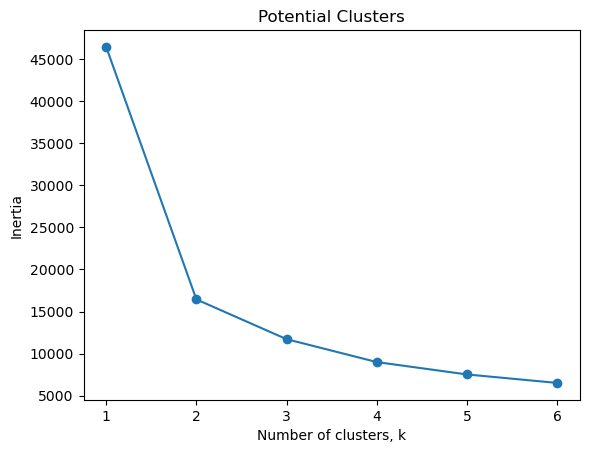

In [213]:
# Determine the number of clusters
ks = range(1,7)
inertias = []

for k in ks:
    # Create a KMeans instance with k clusters
    model = KMeans(n_clusters = k)
    # Fit model to samples
    model.fit(segmentation)
    # Append the inertia to the list of inertias
    inertias.append(model.inertia_)

# Plot the ks vs inertia
plt.plot(ks, inertias, '-o')
plt.xlabel('Number of clusters, k')
plt.ylabel('Inertia')
plt.xticks(ks)
plt.title('Potential Clusters')
plt.show()

In [214]:
# Make a pipeline to scale and fit data into clusters
# Create scaler
scaler = StandardScaler()

# Create KMeans instance
kmeans = KMeans(n_clusters = 3, random_state=42)

# Create pipeline
pipeline = make_pipeline(scaler, kmeans)

In [215]:
# Fit the pipeline to samples
pipeline.fit(segmentation)

# Calculate the cluster labels
labels = pipeline.predict(segmentation)
df_labeled = pd.DataFrame({"cluster_id": labels})

c:\Users\uyen\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


In [216]:
# Concatenate the labels back to segmentation
segmentation = pd.concat([segmentation, df_labeled], axis = 1)
segmentation.head()

,engagement_time,engagement_frequency,cluster_id
0,5.55,7,1
1,5.12,12,0
2,4.25,4,1
3,8.54,15,0
4,12.12,20,2


In [217]:
# Calculate the average values of each cluster
analysis = segmentation.groupby('cluster_id')[["engagement_time", "engagement_frequency"]].mean()
analysis = round(analysis,2)

In [218]:
analysis

,engagement_time,engagement_frequency
cluster_id,,
0,6.51,18.15
1,4.09,5.42
2,9.29,9.59
